# Text Analytics Coursework

This notebook provides some example code for loading and examining the dataset for task 1. 

In [2]:
%load_ext autoreload
%autoreload 2

# Use HuggingFace's datasets library to access the Emotion dataset
from datasets import load_dataset
import numpy as np
import pandas as pd

# Task 1 - PubMedQA

Steps:
* Import the dataset
* Medical QA pipeline: baseline system
* Evaluation -- some simple metrics as an example; a naive baseline as input to the example

In [4]:
# Load PubMedQA (the main labeled split is "pqa_labeled"). 
# The other splits are "pqa_unlabeled", which has no yes/no/maybe labels, 
# and "pqa_artificial", which consists of automatically generated 
# questions and answers. 
dataset = load_dataset("pubmed_qa", "pqa_labeled")

# Inspect the dataset
print(dataset)

# Look at the first example
print(dataset["train"][0])

DatasetDict({
    train: Dataset({
        features: ['pubid', 'question', 'context', 'long_answer', 'final_decision'],
        num_rows: 1000
    })
})
{'pubid': 21645374, 'question': 'Do mitochondria play a role in remodelling lace plant leaves during programmed cell death?', 'context': {'contexts': ['Programmed cell death (PCD) is the regulated death of cells within an organism. The lace plant (Aponogeton madagascariensis) produces perforations in its leaves through PCD. The leaves of the plant consist of a latticework of longitudinal and transverse veins enclosing areoles. PCD occurs in the cells at the center of these areoles and progresses outwards, stopping approximately five cells from the vasculature. The role of mitochondria during PCD has been recognized in animals; however, it has been less studied during PCD in plants.', 'The following paper elucidates the role of mitochondrial dynamics during developmentally regulated PCD in vivo in A. madagascariensis. A single areole wi

To access the important fields:

In [6]:
example = dataset["train"][0]

question = example["question"]
context_paragraphs = example["context"]["contexts"]
label = example["final_decision"]

print("Question:", question)
print("Label:", label)
print("What is inside the context? These are the keys to the context dictionary:", list(example["context"].keys()))
print("The 'context' is an abstract that has been split into paragraphs. \n First context paragraph:", context_paragraphs[0])

Question: Do mitochondria play a role in remodelling lace plant leaves during programmed cell death?
Label: yes
What is inside the context? These are the keys to the context dictionary: ['contexts', 'labels', 'meshes', 'reasoning_required_pred', 'reasoning_free_pred']
The 'context' is an abstract that has been split into paragraphs. 
 First context paragraph: Programmed cell death (PCD) is the regulated death of cells within an organism. The lace plant (Aponogeton madagascariensis) produces perforations in its leaves through PCD. The leaves of the plant consist of a latticework of longitudinal and transverse veins enclosing areoles. PCD occurs in the cells at the center of these areoles and progresses outwards, stopping approximately five cells from the vasculature. The role of mitochondria during PCD has been recognized in animals; however, it has been less studied during PCD in plants.


Combine context paragraphs (common preprocessing step)

In [8]:
def build_context(example):
    example["combined_context"] = " ".join(example["context"]["contexts"])
    return example

dataset = dataset.map(build_context)

print(dataset["train"][0]["combined_context"][:500])

Programmed cell death (PCD) is the regulated death of cells within an organism. The lace plant (Aponogeton madagascariensis) produces perforations in its leaves through PCD. The leaves of the plant consist of a latticework of longitudinal and transverse veins enclosing areoles. PCD occurs in the cells at the center of these areoles and progresses outwards, stopping approximately five cells from the vasculature. The role of mitochondria during PCD has been recognized in animals; however, it has b


The short answers are stored in the field "final_decision" and can take the following values: 

In [10]:
np.unique(dataset["train"]["final_decision"])

array(['maybe', 'no', 'yes'], dtype='<U5')

The long answers look like this and your system could either extract the answer sentences from the context or generate them. Producing long answers is optional.

In [12]:
dataset["train"][0]["long_answer"]

'Results depicted mitochondrial dynamics in vivo as PCD progresses within the lace plant, and highlight the correlation of this organelle with other organelles during developmental PCD. To the best of our knowledge, this is the first report of mitochondria and chloroplasts moving on transvacuolar strands to form a ring structure surrounding the nucleus during developmental PCD. Also, for the first time, we have shown the feasibility for the use of CsA in a whole plant system. Overall, our findings implicate the mitochondria as playing a critical and early role in developmentally regulated PCD in the lace plant.'

In [13]:
!pip install openai python-dotenv tqdm

   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   - -------------------------------------- 0.0/1.2 MB ? eta -:--:--
   ---- ----------------------------------- 0.1/1.2 MB 1.8 MB/s eta 0:00:01
   ---- ----------------------------------- 0.1/1.2 MB 1.8 MB/s eta 0:00:01
   ------- -------------------------------- 0.2/1.2 MB 1.5 MB/s eta 0:00:01
   ---------- ----------------------------- 0.3/1.2 MB 1.8 MB/s eta 0:00:01
   ------------ --------------------------- 0.4/1.2 MB 1.9 MB/s eta 0:00:01
   --------------- ------------------------ 0.5/1.2 MB 2.0 MB/s eta 0:00:01
   ------------------ --------------------- 0.5/1.2 MB 1.9 MB/s eta 0:00:01
   ---------------------- ----------------- 0.7/1.2 MB 2.0 MB/s eta 0:00:01
   ------------------------ --------------- 0.7/1.2 MB 2.0 MB/s eta 0:00:01
   --------------------------- ------------ 0.8/1.2 MB 2.0 MB/s eta 0:00:01
   ----------------------------- ---------- 0.9/1.2 MB 2.0 MB/s eta 0:00:01
   -----------------------

In [14]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from dotenv import load_dotenv

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from openai import OpenAI

In [15]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

LABEL2ID = {"yes": 0, "no": 1, "maybe": 2}
ID2LABEL = {0: "yes", 1: "no", 2: "maybe"}

load_dotenv()

api_key = os.getenv("OPENAI_API_KEY")
if not api_key:
    raise ValueError("OPENAI_API_KEY not found. Please create a .env file and put it in the notebook folder.")

client = OpenAI(api_key=api_key)
print("API key loaded successfully.")

API key loaded successfully.


In [16]:
df = pd.DataFrame({
    "question": dataset["train"]["question"],
    "context": dataset["train"]["combined_context"],
    "long_answer": dataset["train"]["long_answer"],
    "label": dataset["train"]["final_decision"]
})

df["label_id"] = df["label"].map(LABEL2ID)

print("Total size:", len(df))
print(df["label"].value_counts())
print(df["label"].value_counts(normalize=True))

Total size: 1000
label
yes      552
no       338
maybe    110
Name: count, dtype: int64
label
yes      0.552
no       0.338
maybe    0.110
Name: proportion, dtype: float64


In [17]:
train_df, val_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=df["label_id"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("Train:", len(train_df))
print("Validation:", len(val_df))

Train: 700
Validation: 300


In [18]:
def sample_few_shot_examples(train_df, n_per_class=2):
    examples = []
    for label in ["yes", "no", "maybe"]:
        subset = train_df[train_df["label"] == label].sample(
            n=min(n_per_class, len(train_df[train_df["label"] == label])),
            random_state=SEED
        )
        for _, row in subset.iterrows():
            examples.append({
                "question": row["question"],
                "context": row["context"],
                "label": row["label"]
            })
    return examples

few_shot_examples = sample_few_shot_examples(train_df, n_per_class=2)

def build_examples_text(examples):
    blocks = []
    for i, ex in enumerate(examples, start=1):
        block = f"""Example {i}
Question: {ex["question"]}
Context: {ex["context"]}
Answer label: {ex["label"]}"""
        blocks.append(block)
    return "\n\n".join(blocks)

few_shot_text = build_examples_text(few_shot_examples)
print(few_shot_text[:2000])

Example 1
Question: School food policy at Dutch primary schools: room for improvement?
Context: Schools can play an important role in the prevention of obesity, e.g. by providing an environment that stimulates healthy eating habits and by developing a food policy to provide such an environment. The effectiveness of a school food policy is affected by the content of the policy, its implementation and its support by parents, teachers and principals. The aim of this study is to detect opportunities to improve the school food policy and/or implementation at Dutch primary schools. Therefore, this study explores the school food policy and investigates schools' (teachers and principals) and parents' opinion on the school food policy. Data on the schools' perspective of the food policy was collected from principals and teachers by means of semi-structured interviews. In total 74 principals and 72 teachers from 83 Dutch primary schools were interviewed. Data on parental perceptions about the sc

In [19]:
def build_prompt(question, context, few_shot_text):
    prompt = f"""
You are solving a biomedical question answering classification task.

Task:
Given a biomedical question and its abstract context, predict the final short answer label:
- yes
- no
- maybe

Important rules:
1. Use only the information in the question and context.
2. Do not use outside medical knowledge.
3. If the evidence is uncertain, mixed, conditional, or inconclusive, choose "maybe".
4. Return only one label.
5. Also provide a short one-sentence explanation.

Here are some labeled training examples:

{few_shot_text}

Now classify this new example.

Question: {question}

Context: {context}
"""
    return prompt.strip()

In [20]:
def predict_with_gpt(question, context, few_shot_text, model="gpt-5"):
    prompt = build_prompt(question, context, few_shot_text)

    response = client.responses.create(
        model=model,
        instructions=(
            "You are a careful biomedical QA classifier. "
            "Always follow the schema exactly."
        ),
        input=prompt,
        temperature=0,
        max_output_tokens=200,
        text={
            "format": {
                "type": "json_schema",
                "name": "pubmedqa_prediction",
                "schema": {
                    "type": "object",
                    "properties": {
                        "label": {
                            "type": "string",
                            "enum": ["yes", "no", "maybe"]
                        },
                        "confidence": {
                            "type": "number"
                        },
                        "reason": {
                            "type": "string"
                        }
                    },
                    "required": ["label", "confidence", "reason"],
                    "additionalProperties": False
                },
                "strict": True
            }
        }
    )

    output_text = response.output_text
    result = json.loads(output_text)
    return result

In [21]:
def build_prompt_long_answer(question, context, long_answer, few_shot_text):
    prompt = f"""
You are solving a biomedical question answering classification task.

Task:
Given a biomedical question, its abstract context, and a candidate long answer, predict the final short answer label:
- yes
- no
- maybe

Important rules:
1. Use the context as the main evidence.
2. Use the long answer as supporting evidence.
3. Do not use outside medical knowledge.
4. If the evidence is uncertain, mixed, conditional, or inconclusive, choose "maybe".
5. Return exactly one label, one confidence score, and one short explanation.

Here are some labeled training examples:

{few_shot_text}

Now classify this new example.

Question: {question}

Context: {context}

Candidate long answer: {long_answer}
"""
    return prompt.strip()

In [22]:
def predict_with_gpt_long_answer(question, context, long_answer, few_shot_text, model="gpt-5.4-mini"):
    prompt = build_prompt_long_answer(question, context, long_answer, few_shot_text)

    response = client.responses.create(
        model=model,
        instructions=(
            "You are a careful biomedical QA classifier. "
            "Always follow the schema exactly."
        ),
        input=prompt,
        temperature=0,
        max_output_tokens=200,
        text={
            "format": {
                "type": "json_schema",
                "name": "pubmedqa_prediction",
                "schema": {
                    "type": "object",
                    "properties": {
                        "label": {
                            "type": "string",
                            "enum": ["yes", "no", "maybe"]
                        },
                        "confidence": {
                            "type": "number"
                        },
                        "reason": {
                            "type": "string"
                        }
                    },
                    "required": ["label", "confidence", "reason"],
                    "additionalProperties": False
                },
                "strict": True
            }
        }
    )

    output_text = response.output_text
    result = json.loads(output_text)
    return result

In [23]:
pred_records = []

for idx, row in tqdm(val_df.iterrows(), total=len(val_df)):
    try:
        result = predict_with_gpt(
            question=row["question"],
            context=row["context"],
            few_shot_text=few_shot_text,
            model="gpt-5.4-mini"
        )

        pred_label = result["label"]
        pred_records.append({
            "index": idx,
            "question": row["question"],
            "true_label": row["label"],
            "pred_label": pred_label,
            "confidence": result["confidence"],
            "reason": result["reason"]
        })
    except Exception as e:
        pred_records.append({
            "index": idx,
            "question": row["question"],
            "true_label": row["label"],
            "pred_label": "ERROR",
            "confidence": None,
            "reason": str(e)
        })

pred_df = pd.DataFrame(pred_records)
pred_df.head()

100%|████████████████████████████████████████████████████████████████████████████████| 300/300 [07:08<00:00,  1.43s/it]


,index,question,true_label,pred_label,confidence,reason
0,0,Can dogs prime autistic children for therapy?,yes,yes,0.93,The context reports that in the presence of th...
1,1,Is there a discrepancy between patient and phy...,yes,yes,0.96,The context reports relatively poor concordanc...
2,2,Can bedside assessment reliably exclude aspira...,no,no,0.98,Bedside assessment missed aspiration in 10 of ...
3,3,Landolt C and snellen e acuity: differences in...,no,yes,0.86,The context reports that in eyes with strabism...
4,4,Bony defects in chronic anterior posttraumatic...,no,no,0.98,The study found no significant correlation bet...


In [24]:
eval_df = pred_df[pred_df["pred_label"].isin(["yes", "no", "maybe"])].copy()

y_true = eval_df["true_label"].map(LABEL2ID).values
y_pred = eval_df["pred_label"].map(LABEL2ID).values

gpt_acc = accuracy_score(y_true, y_pred)
gpt_f1 = f1_score(y_true, y_pred, average="macro")

print("GPT validation accuracy:", gpt_acc)
print("GPT validation macro-F1:", gpt_f1)
print(classification_report(
    y_true,
    y_pred,
    target_names=["yes", "no", "maybe"],
    zero_division=0
))

GPT validation accuracy: 0.69
GPT validation macro-F1: 0.5864813528569606
              precision    recall  f1-score   support

         yes       0.82      0.74      0.78       166
          no       0.84      0.74      0.79       101
       maybe       0.15      0.27      0.19        33

    accuracy                           0.69       300
   macro avg       0.60      0.59      0.59       300
weighted avg       0.75      0.69      0.72       300



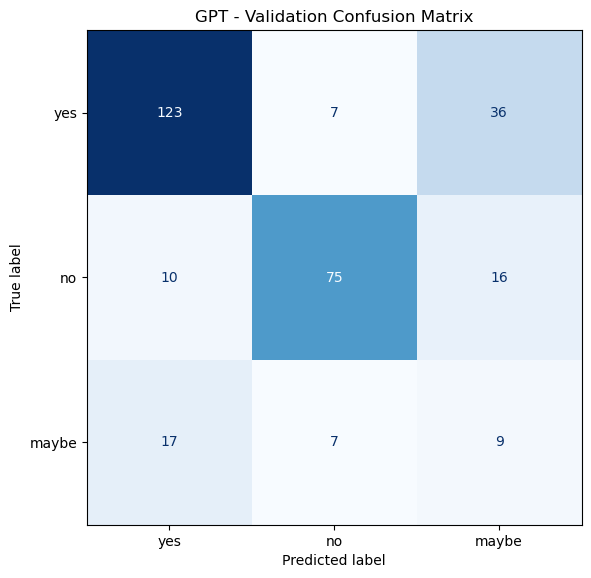

In [25]:
cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["yes", "no", "maybe"]
)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
plt.title("GPT - Validation Confusion Matrix")
plt.tight_layout()
plt.show()

In [26]:
baseline_pred_df = pred_df.copy()
baseline_eval_df = eval_df.copy()

baseline_y_true = y_true.copy()
baseline_y_pred = y_pred.copy()

baseline_acc = gpt_acc
baseline_f1 = gpt_f1
baseline_cm = cm.copy()

In [27]:
long_answer_pred_records = []

for idx, row in tqdm(val_df.iterrows(), total=len(val_df)):
    try:
        result = predict_with_gpt_long_answer(
            question=row["question"],
            context=row["context"],
            long_answer=row["long_answer"],
            few_shot_text=few_shot_text,
            model="gpt-5.4-mini"
        )

        long_answer_pred_records.append({
            "index": idx,
            "question": row["question"],
            "true_label": row["label"],
            "pred_label": result["label"],
            "confidence": result["confidence"],
            "reason": result["reason"]
        })
    except Exception as e:
        long_answer_pred_records.append({
            "index": idx,
            "question": row["question"],
            "true_label": row["label"],
            "pred_label": "ERROR",
            "confidence": None,
            "reason": str(e)
        })

long_answer_pred_df = pd.DataFrame(long_answer_pred_records)
long_answer_pred_df.head()

100%|████████████████████████████████████████████████████████████████████████████████| 300/300 [08:11<00:00,  1.64s/it]


,index,question,true_label,pred_label,confidence,reason
0,0,Can dogs prime autistic children for therapy?,yes,yes,0.95,"The context reports that, with a therapy dog p..."
1,1,Is there a discrepancy between patient and phy...,yes,yes,0.97,The context reports relatively poor concordanc...
2,2,Can bedside assessment reliably exclude aspira...,no,no,0.97,The context reports that bedside assessment mi...
3,3,Landolt C and snellen e acuity: differences in...,no,yes,0.95,The context and long answer both state that Sn...
4,4,Bony defects in chronic anterior posttraumatic...,no,no,0.98,The context explicitly states that no signific...


In [28]:
long_answer_eval_df = long_answer_pred_df[
    long_answer_pred_df["pred_label"].isin(["yes", "no", "maybe"])
].copy()

long_answer_y_true = long_answer_eval_df["true_label"].map(LABEL2ID).values
long_answer_y_pred = long_answer_eval_df["pred_label"].map(LABEL2ID).values

long_answer_acc = accuracy_score(long_answer_y_true, long_answer_y_pred)
long_answer_f1 = f1_score(long_answer_y_true, long_answer_y_pred, average="macro")

print("GPT + long answer validation accuracy:", long_answer_acc)
print("GPT + long answer validation macro-F1:", long_answer_f1)
print(classification_report(
    long_answer_y_true,
    long_answer_y_pred,
    target_names=["yes", "no", "maybe"],
    zero_division=0
))

GPT + long answer validation accuracy: 0.7466666666666667
GPT + long answer validation macro-F1: 0.6289156812022666
              precision    recall  f1-score   support

         yes       0.85      0.79      0.82       166
          no       0.87      0.83      0.85       101
       maybe       0.18      0.27      0.22        33

    accuracy                           0.75       300
   macro avg       0.63      0.63      0.63       300
weighted avg       0.78      0.75      0.76       300



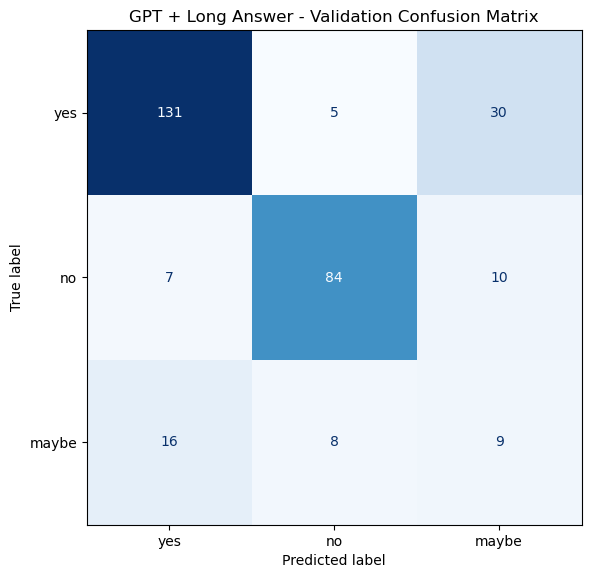

In [29]:
long_answer_cm = confusion_matrix(long_answer_y_true, long_answer_y_pred, labels=[0, 1, 2])

disp = ConfusionMatrixDisplay(
    confusion_matrix=long_answer_cm,
    display_labels=["yes", "no", "maybe"]
)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
plt.title("GPT + Long Answer - Validation Confusion Matrix")
plt.tight_layout()
plt.show()

In [30]:
results_df = pd.DataFrame([
    {
        "model": "GPT few-shot baseline",
        "val_accuracy": baseline_acc,
        "val_macro_f1": baseline_f1,
        "best_params": "N/A"
    },
    {
        "model": "GPT few-shot + long answer",
        "val_accuracy": long_answer_acc,
        "val_macro_f1": long_answer_f1,
        "best_params": "N/A"
    }
])

results_df = results_df.sort_values(by="val_macro_f1", ascending=False).reset_index(drop=True)
results_df

,model,val_accuracy,val_macro_f1,best_params
0,GPT few-shot + long answer,0.746667,0.628916,N/A
1,GPT few-shot baseline,0.690000,0.586481,N/A


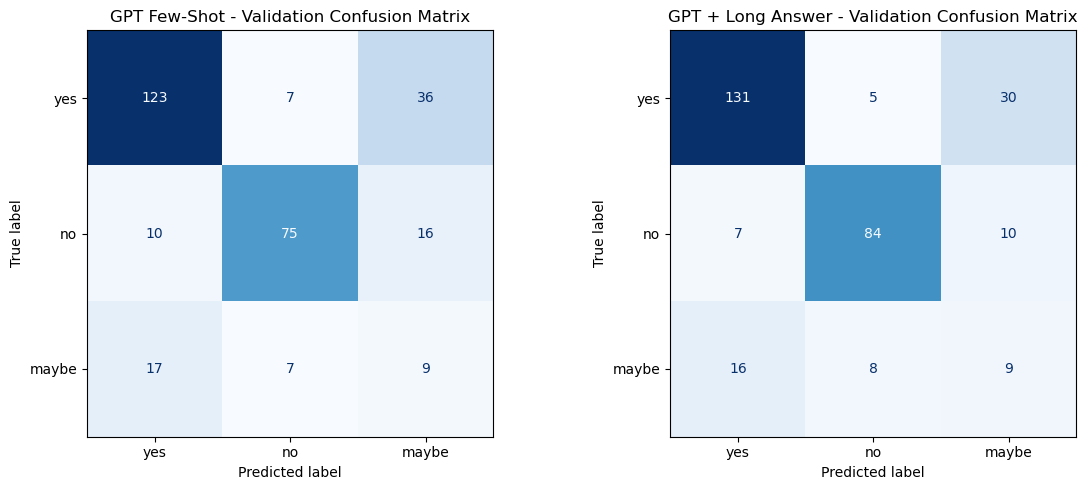

In [31]:
label_names = ["yes", "no", "maybe"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

disp_baseline = ConfusionMatrixDisplay(
    confusion_matrix=baseline_cm,
    display_labels=label_names
)
disp_baseline.plot(ax=axes[0], cmap="Blues", values_format="d", colorbar=False)
axes[0].set_title("GPT Few-Shot - Validation Confusion Matrix")

disp_long_answer = ConfusionMatrixDisplay(
    confusion_matrix=long_answer_cm,
    display_labels=label_names
)
disp_long_answer.plot(ax=axes[1], cmap="Blues", values_format="d", colorbar=False)
axes[1].set_title("GPT + Long Answer - Validation Confusion Matrix")

plt.tight_layout()
plt.show()